In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

df = pd.read_csv('dataset/blockchain_transactions.csv')

print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Shape: (10206, 13)
Memory: 5.74 MB


In [2]:
print("=== INFO ===")
df.info()

print("\n=== 5 BARIS PERTAMA ===")
print(df.head())

print("\n=== 5 BARIS ACAK ===")
print(df.sample(5, random_state=42))

=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 10206 entries, 0 to 10205
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   block_index          10206 non-null  int64  
 1   block_timestamp      10206 non-null  float64
 2   block_miner_id       10206 non-null  str    
 3   tx_id                10205 non-null  str    
 4   tx_timestamp         10205 non-null  float64
 5   tx_type              10205 non-null  str    
 6   tx_sender            10205 non-null  str    
 7   tx_recipient         10205 non-null  str    
 8   tx_amount            10205 non-null  float64
 9   tx_energy            10205 non-null  float64
 10  block_hash           10206 non-null  str    
 11  block_previous_hash  10206 non-null  str    
 12  block_nonce          10206 non-null  int64  
dtypes: float64(4), int64(2), str(7)
memory usage: 1.0 MB

=== 5 BARIS PERTAMA ===
   block_index    block_timestamp block_miner_id  \
0   

In [3]:
print("=== MISSING VALUES ===")
missing = pd.DataFrame({
    'n_missing': df.isnull().sum(),
    'pct_missing': df.isnull().mean() * 100
})
print(missing[missing['n_missing'] > 0] if missing['n_missing'].sum() > 0 
      else "Tidak ada missing values")

print(f"\n=== DUPLIKAT ===")
print(f"Baris duplikat penuh: {df.duplicated().sum()}")

=== MISSING VALUES ===
              n_missing  pct_missing
tx_id                 1       0.0098
tx_timestamp          1       0.0098
tx_type               1       0.0098
tx_sender             1       0.0098
tx_recipient          1       0.0098
tx_amount             1       0.0098
tx_energy             1       0.0098

=== DUPLIKAT ===
Baris duplikat penuh: 0


In [4]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Kolom numerik ({len(num_cols)}): {num_cols}\n")

desc = df[num_cols].describe().T
desc['skew'] = df[num_cols].skew()
desc['kurtosis'] = df[num_cols].kurtosis()
print(desc)

Kolom numerik (6): ['block_index', 'block_timestamp', 'tx_timestamp', 'tx_amount', 'tx_energy', 'block_nonce']

                      count               mean        std                min  \
block_index     10,206.0000           243.3608   140.7881             0.0000   
block_timestamp 10,206.0000 1,753,188,308.4417 2,058.5122 1,753,184,695.0558   
tx_timestamp    10,205.0000 1,753,188,308.7876 2,058.2979 1,753,184,805.0682   
tx_amount       10,205.0000             0.1783     0.1318             0.0022   
tx_energy       10,205.0000             0.4454     0.6356             0.0000   
block_nonce     10,206.0000           261.1494   251.1525             0.0000   

                               25%                50%                75%  \
block_index               122.0000           240.0000           366.0000   
block_timestamp 1,753,186,522.6101 1,753,188,225.5560 1,753,190,109.1768   
tx_timestamp    1,753,186,522.6057 1,753,188,225.5473 1,753,190,109.1670   
tx_amount              

In [5]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Kolom non-numerik ({len(cat_cols)}): {cat_cols}\n")

for col in cat_cols:
    n_unique = df[col].nunique()
    print(f"--- {col} ---")
    print(f"  Unique: {n_unique} ({n_unique/len(df)*100:.1f}% dari total baris)")
    if n_unique <= 20:
        print(df[col].value_counts())
    else:
        print(f"  Top 5:\n{df[col].value_counts().head()}")
    print()

Kolom non-numerik (7): ['block_miner_id', 'tx_id', 'tx_type', 'tx_sender', 'tx_recipient', 'block_hash', 'block_previous_hash']

--- block_miner_id ---
  Unique: 2 (0.0% dari total baris)
block_miner_id
GRID-OP-01    10205
genesis           1
Name: count, dtype: int64

--- tx_id ---
  Unique: 10205 (100.0% dari total baris)
  Top 5:
tx_id
21eed0258f184cc8ab97382ff638b9a1    1
23268eea91b84e1b847115b1515c64e4    1
1b3cc40f30ce4fb7a5cfef36fe05e932    1
1d990f952b384f508c9b28583fc83959    1
23376b2b4f924d0db6e1503d811a6689    1
Name: count, dtype: int64

--- tx_type ---
  Unique: 2 (0.0% dari total baris)
tx_type
energy_delivery    5193
energy_payment     5012
Name: count, dtype: int64

--- tx_sender ---
  Unique: 23 (0.2% dari total baris)
  Top 5:
tx_sender
GRID-OP-01    5193
CON-03         436
CON-10         327
CON-17         289
CON-06         277
Name: count, dtype: int64

--- tx_recipient ---
  Unique: 30 (0.3% dari total baris)
  Top 5:
tx_recipient
PRO-05    848
PRO-02    835
PRO

C:\Users\Acer\AppData\Local\Temp\ipykernel_42284\3518603767.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


In [6]:
# Cari kolom yang kemungkinan timestamp
candidates = [c for c in df.columns if any(k in c.lower() 
              for k in ['time', 'date', 'stamp', 'block'])]
print(f"Kandidat kolom waktu: {candidates}\n")

for col in candidates:
    print(f"--- {col} ---")
    print(df[col].head(3).tolist())
    print(f"dtype: {df[col].dtype}\n")

Kandidat kolom waktu: ['block_index', 'block_timestamp', 'block_miner_id', 'tx_timestamp', 'block_hash', 'block_previous_hash', 'block_nonce']

--- block_index ---
[0, 1, 1]
dtype: int64

--- block_timestamp ---
[1753184695.0558405, 1753184805.068432, 1753184805.068432]
dtype: float64

--- block_miner_id ---
['genesis', 'GRID-OP-01', 'GRID-OP-01']
dtype: str

--- tx_timestamp ---
[nan, 1753184805.0681646, 1753184805.0681534]
dtype: float64

--- block_hash ---
['00a0c15fca506230353c4f5a8452da5fdbc6b4c5ad25ea33da766d6de553d968', '00b70fbea4dcce4d9d0d654feb04081376007cefd82d86c23c4187beb755da71', '00b70fbea4dcce4d9d0d654feb04081376007cefd82d86c23c4187beb755da71']
dtype: str

--- block_previous_hash ---
['0', '00a0c15fca506230353c4f5a8452da5fdbc6b4c5ad25ea33da766d6de553d968', '00a0c15fca506230353c4f5a8452da5fdbc6b4c5ad25ea33da766d6de553d968']
dtype: str

--- block_nonce ---
[886, 292, 292]
dtype: int64



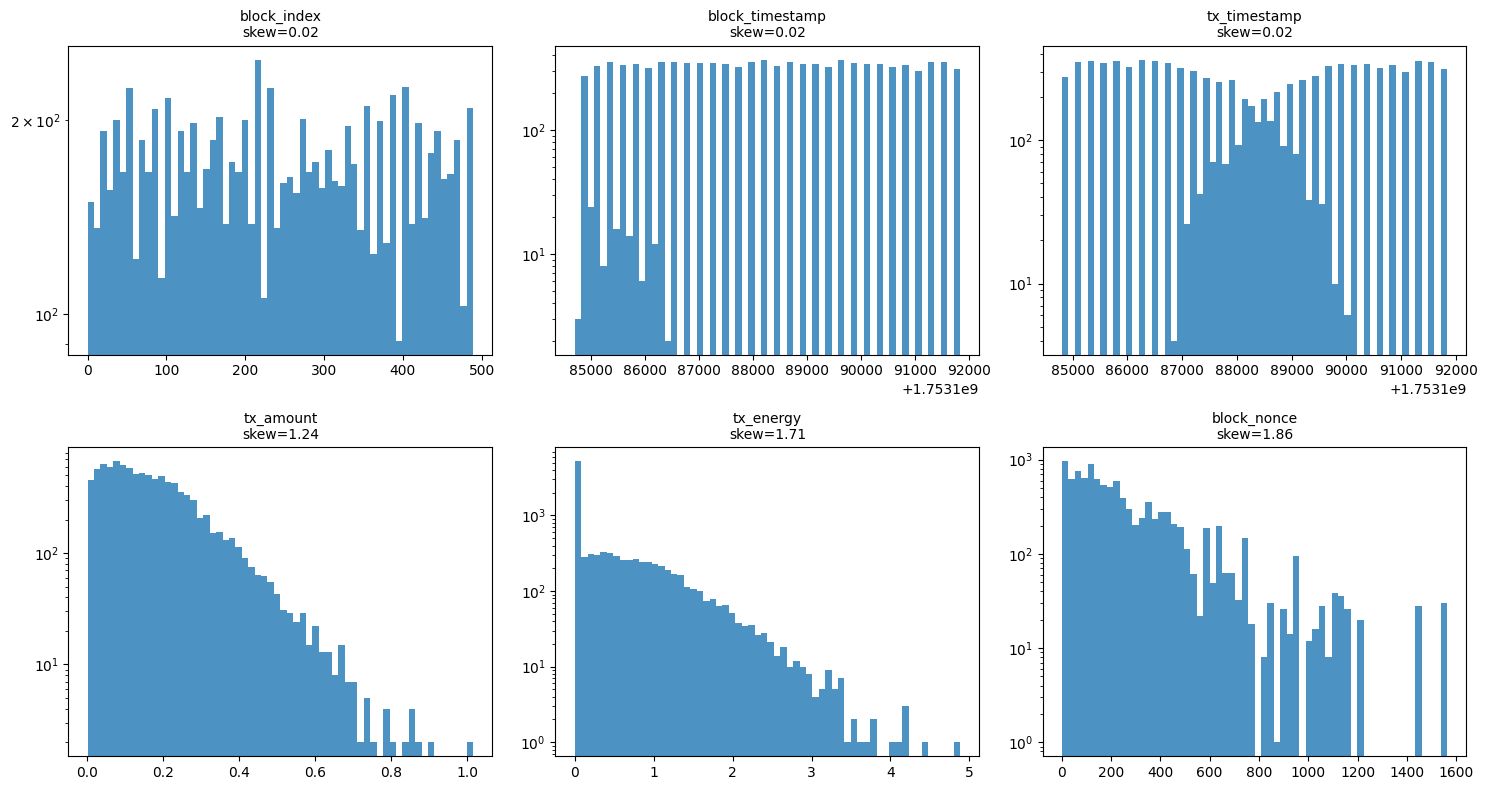

In [7]:
n = len(num_cols)
ncols = 3
nrows = -(-n // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = np.array(axes).flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=60, edgecolor='none', alpha=0.8)
    axes[i].set_title(f"{col}\nskew={df[col].skew():.2f}", fontsize=10)
    axes[i].set_yscale('log')  # <- penting, lihat penjelasan

for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

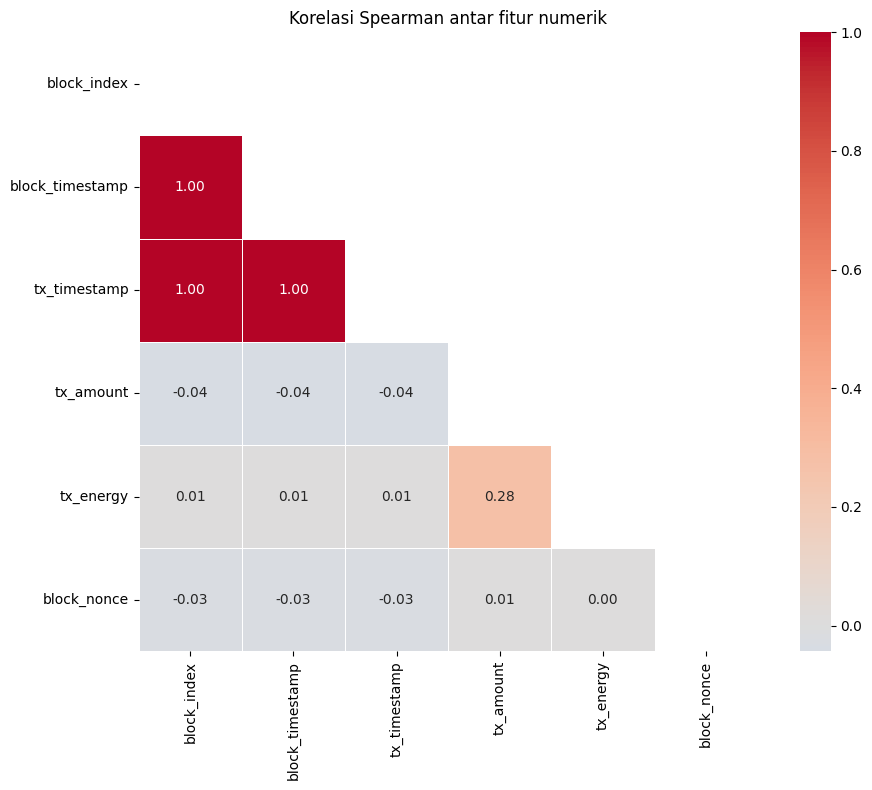

In [8]:
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Korelasi Spearman antar fitur numerik')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=100, bbox_inches='tight')
plt.show()

# Cell 9

In [9]:
# Pisahkan genesis dari transaksi
tx = df[df['tx_id'].notna()].copy()
print(f"Transaksi valid: {len(tx)}")

delivery = tx[tx['tx_type'] == 'energy_delivery']
payment  = tx[tx['tx_type'] == 'energy_payment']
print(f"Delivery: {len(delivery)}, Payment: {len(payment)}, Selisih: {len(delivery)-len(payment)}")

# Statistik terstratifikasi — bandingkan dengan Cell 4 yang tercampur
print("\n=== tx_amount per tipe ===")
print(tx.groupby('tx_type')['tx_amount'].describe())
print("\n=== tx_energy per tipe ===")
print(tx.groupby('tx_type')['tx_energy'].describe())

Transaksi valid: 10205
Delivery: 5193, Payment: 5012, Selisih: 181

=== tx_amount per tipe ===
                     count   mean    std    min    25%    50%    75%    max
tx_type                                                                    
energy_delivery 5,193.0000 0.1792 0.1325 0.0022 0.0780 0.1536 0.2486 1.0154
energy_payment  5,012.0000 0.1773 0.1311 0.0022 0.0769 0.1521 0.2464 1.0154

=== tx_energy per tipe ===
                     count   mean    std    min    25%    50%    75%    max
tx_type                                                                    
energy_delivery 5,193.0000 0.8753 0.6461 0.0109 0.3797 0.7506 1.2147 4.8825
energy_payment  5,012.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000


count   5,193.0000
mean        0.2047
std         0.0037
min         0.1995
25%         0.2020
50%         0.2047
75%         0.2072
max         0.2907
dtype: float64

Coefficient of variation: 1.79%


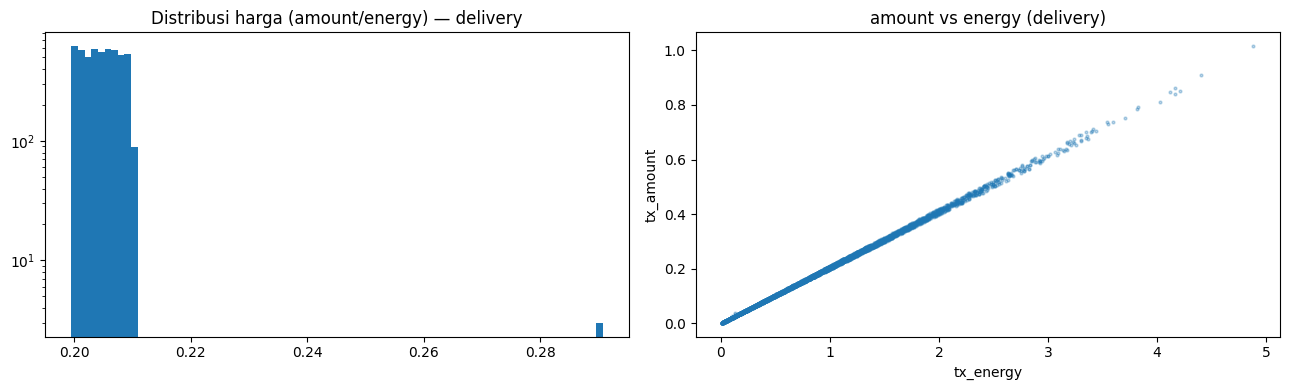


Delivery dengan deviasi harga >5% dari median: 3
Delivery dengan deviasi harga >20% dari median: 3


In [10]:
price = delivery['tx_amount'] / delivery['tx_energy']
print(price.describe())
print(f"\nCoefficient of variation: {price.std()/price.mean()*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(price, bins=80)
axes[0].set_yscale('log')
axes[0].set_title('Distribusi harga (amount/energy) — delivery')

axes[1].scatter(delivery['tx_energy'], delivery['tx_amount'], s=4, alpha=0.3)
axes[1].set_xlabel('tx_energy'); axes[1].set_ylabel('tx_amount')
axes[1].set_title('amount vs energy (delivery)')
plt.tight_layout(); plt.show()

# Berapa banyak yang menyimpang dari harga median?
dev = (price - price.median()).abs() / price.median()
print(f"\nDelivery dengan deviasi harga >5% dari median: {(dev > 0.05).sum()}")
print(f"Delivery dengan deviasi harga >20% dari median: {(dev > 0.20).sum()}")

In [11]:
# Hipotesis: tiap delivery (GRID→CON-x) berpasangan dengan payment (CON-x→PRO-y)
# dengan tx_amount identik, di blok yang sama atau berdekatan
merged = delivery.merge(
    payment,
    left_on=['tx_recipient', 'tx_amount'],   # konsumen penerima energi
    right_on=['tx_sender', 'tx_amount'],     # konsumen pembayar
    suffixes=('_del', '_pay'),
    how='left'
)
n_unpaired = merged['tx_id_pay'].isna().sum()
print(f"Delivery tanpa payment yang cocok (recipient+amount): {n_unpaired}")

# Siapa konsumen yang paling sering tidak membayar?
unpaired = merged[merged['tx_id_pay'].isna()]
print("\nKonsumen dengan delivery tak berpasangan:")
print(unpaired['tx_recipient_del'].value_counts().head(10))

# Kapan delivery tak berpasangan ini terjadi?
print("\nRentang waktu delivery tak berpasangan:")
print(f"  min: {unpaired['tx_timestamp_del'].min():,.0f}")
print(f"  max: {unpaired['tx_timestamp_del'].max():,.0f}")

Delivery tanpa payment yang cocok (recipient+amount): 181

Konsumen dengan delivery tak berpasangan:
tx_recipient_del
CON-09    181
Name: count, dtype: int64

Rentang waktu delivery tak berpasangan:
  min: 1,753,188,471
  max: 1,753,191,833


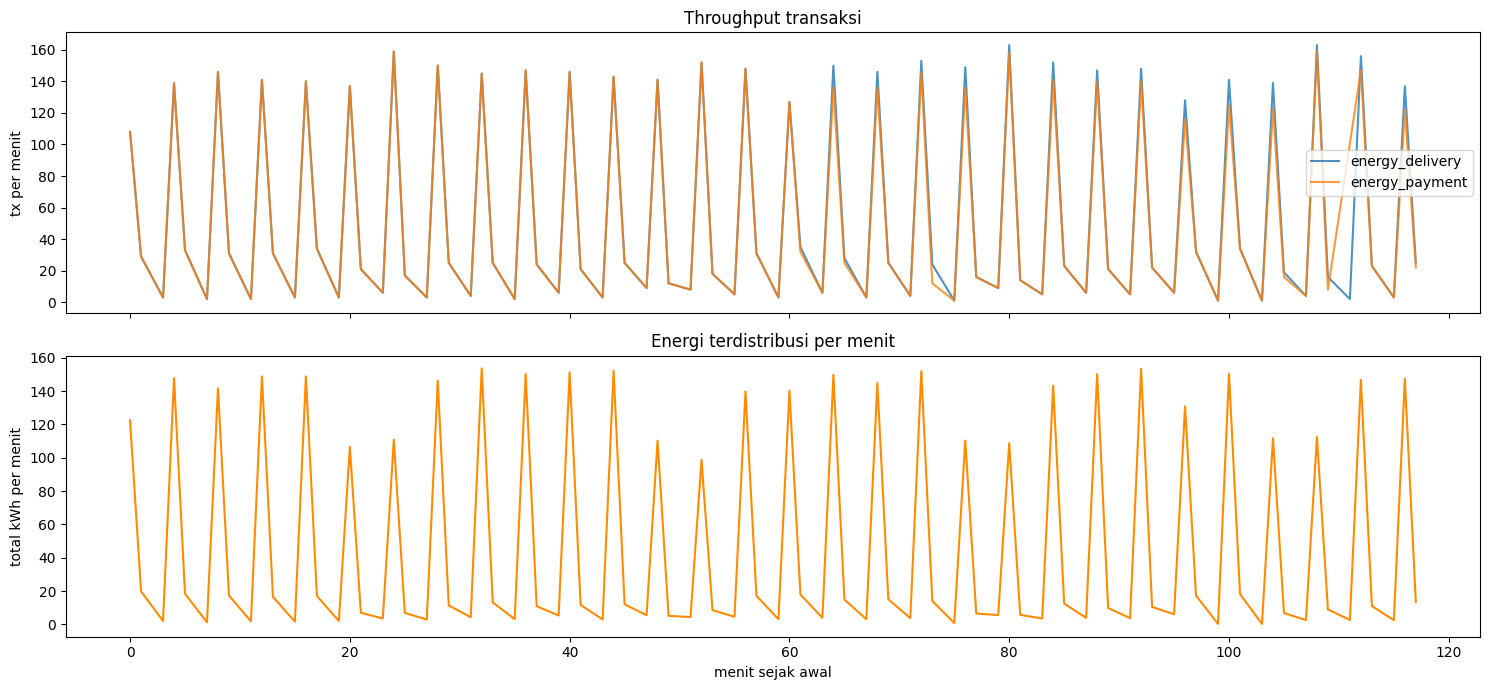

In [12]:
t0 = tx['tx_timestamp'].min()
tx['t_rel'] = tx['tx_timestamp'] - t0  # detik sejak awal simulasi

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

# Throughput per menit, per tipe
for ttype, ax_data in tx.groupby('tx_type'):
    counts = ax_data.groupby((ax_data['t_rel'] // 60).astype(int)).size()
    axes[0].plot(counts.index, counts.values, label=ttype, alpha=0.8)
axes[0].set_ylabel('tx per menit'); axes[0].legend(); axes[0].set_title('Throughput transaksi')

# Total energi terkirim per menit
energy_per_min = delivery.assign(t_rel=delivery['tx_timestamp']-t0) \
    .groupby(lambda i: int((delivery.loc[i,'tx_timestamp']-t0)//60))['tx_energy'].sum() \
    if False else \
    delivery.assign(minute=((delivery['tx_timestamp']-t0)//60).astype(int)) \
    .groupby('minute')['tx_energy'].sum()
axes[1].plot(energy_per_min.index, energy_per_min.values, color='darkorange')
axes[1].set_ylabel('total kWh per menit'); axes[1].set_xlabel('menit sejak awal')
axes[1].set_title('Energi terdistribusi per menit')
plt.tight_layout(); plt.show()

In [13]:
con_profile = pd.DataFrame({
    'n_delivery_diterima': delivery.groupby('tx_recipient').size(),
    'total_energy': delivery.groupby('tx_recipient')['tx_energy'].sum(),
    'n_payment_dikirim': payment.groupby('tx_sender').size(),
    'total_dibayar': payment.groupby('tx_sender')['tx_amount'].sum(),
    'total_tagihan': delivery.groupby('tx_recipient')['tx_amount'].sum(),
}).fillna(0)
con_profile['selisih_bayar'] = con_profile['total_tagihan'] - con_profile['total_dibayar']
con_profile['rasio_bayar'] = con_profile['total_dibayar'] / con_profile['total_tagihan']
print(con_profile.sort_values('rasio_bayar'))

        n_delivery_diterima  total_energy  n_payment_dikirim  total_dibayar  \
CON-09                  418      475.6337                237        55.4653   
CON-00                  254      243.7067                254        49.8526   
CON-02                  196      138.1062                196        28.3051   
CON-01                  243      181.6740                243        37.1723   
CON-04                  257      244.5715                257        50.1048   
CON-05                  237      204.4841                237        41.9392   
CON-06                  277      257.7482                277        52.7105   
CON-03                  436      556.3311                436       114.0517   
CON-07                  172       98.4910                172        20.1595   
CON-08                  263      201.1467                263        41.1367   
CON-10                  327      351.7561                327        71.9790   
CON-11                  195      132.4896           

count   10,205.0000
mean         0.0081
std          0.0050
min          0.0003
25%          0.0040
50%          0.0077
75%          0.0117
max          0.0241
Name: latency, dtype: float64

Latency negatif (tx 'setelah' blok — mustahil secara kausal): 0


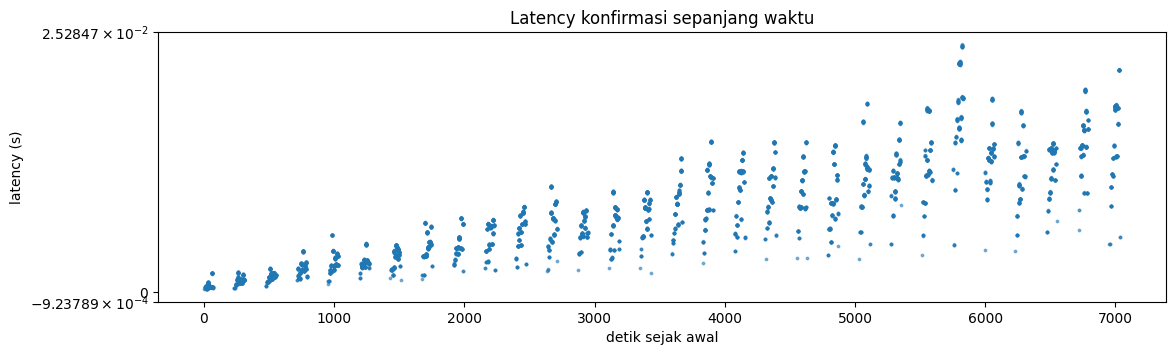


Blok dengan rantai putus: 0 dari 489


In [14]:
tx['latency'] = tx['block_timestamp'] - tx['tx_timestamp']
print(tx['latency'].describe())
print(f"\nLatency negatif (tx 'setelah' blok — mustahil secara kausal): {(tx['latency'] < 0).sum()}")

plt.figure(figsize=(13, 3.5))
plt.scatter(tx['t_rel'], tx['latency'], s=3, alpha=0.3)
plt.xlabel('detik sejak awal'); plt.ylabel('latency (s)')
plt.title('Latency konfirmasi sepanjang waktu')
plt.yscale('symlog')
plt.show()

# Verifikasi integritas rantai: previous_hash blok n == hash blok n-1?
blocks = df.drop_duplicates('block_index').sort_values('block_index')
chain_ok = (blocks['block_previous_hash'].iloc[1:].values == 
            blocks['block_hash'].iloc[:-1].values)
print(f"\nBlok dengan rantai putus: {(~chain_ok).sum()} dari {len(chain_ok)}")

# Cell 15

In [15]:
delivery = delivery.copy()
delivery['price'] = delivery['tx_amount'] / delivery['tx_energy']
med = delivery['price'].median()

suspects = delivery[(delivery['price'] - med).abs() / med > 0.20]
print(suspects[['block_index', 'tx_timestamp', 'tx_recipient', 
                'tx_amount', 'tx_energy', 'price']])

# Konversi ke menit-relatif agar bisa dibandingkan dengan timeline CON-09
t0 = tx['tx_timestamp'].min()
print("\nMenit kejadian:", ((suspects['tx_timestamp'] - t0) / 60).round(1).tolist())

       block_index       tx_timestamp tx_recipient  tx_amount  tx_energy  \
3765           177 1,753,187,278.9145       CON-19     0.0369     0.1272   
5156           243 1,753,188,240.6329       CON-09     0.0364     0.1254   
10202          489 1,753,191,838.3388       CON-10     0.0291     0.1002   

       price  
3765  0.2901  
5156  0.2907  
10202 0.2905  

Menit kejadian: [41.2, 57.3, 117.2]


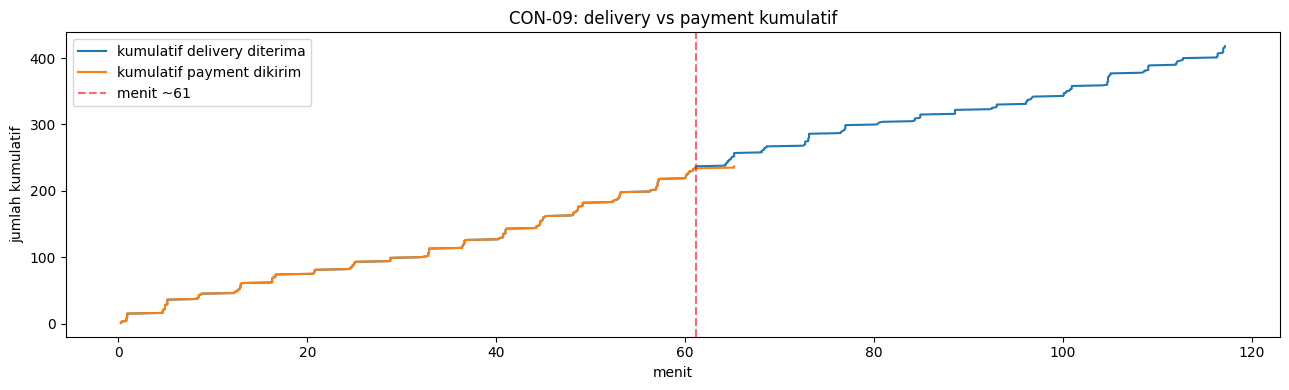

                   count   mean      sum
fase                                    
sebelum (bayar)      233 1.1592 270.0974
sesudah (nunggak)    185 1.1110 205.5364

Laju delivery per menit:
  sebelum: 3.81 delivery/menit
  sesudah: 3.30 delivery/menit


In [16]:
con9_del = delivery[delivery['tx_recipient'] == 'CON-09'].sort_values('tx_timestamp')
con9_pay = payment[payment['tx_sender'] == 'CON-09'].sort_values('tx_timestamp')

plt.figure(figsize=(13, 4))
plt.plot((con9_del['tx_timestamp']-t0)/60, np.arange(1, len(con9_del)+1), 
         label='kumulatif delivery diterima')
plt.plot((con9_pay['tx_timestamp']-t0)/60, np.arange(1, len(con9_pay)+1), 
         label='kumulatif payment dikirim')
plt.axvline(61.1, color='red', ls='--', alpha=0.6, label='menit ~61')
plt.xlabel('menit'); plt.ylabel('jumlah kumulatif')
plt.title('CON-09: delivery vs payment kumulatif')
plt.legend(); plt.tight_layout(); plt.show()

# Apakah konsumsinya berubah setelah berhenti membayar?
con9_del['fase'] = np.where(con9_del['tx_timestamp'] < 1_753_188_471, 
                            'sebelum (bayar)', 'sesudah (nunggak)')
print(con9_del.groupby('fase')['tx_energy'].agg(['count', 'mean', 'sum']))
print("\nLaju delivery per menit:")
durasi_sebelum = (1_753_188_471 - t0) / 60
durasi_sesudah = (tx['tx_timestamp'].max() - 1_753_188_471) / 60
before = con9_del[con9_del['fase']=='sebelum (bayar)']
after  = con9_del[con9_del['fase']=='sesudah (nunggak)']
print(f"  sebelum: {len(before)/durasi_sebelum:.2f} delivery/menit")
print(f"  sesudah: {len(after)/durasi_sesudah:.2f} delivery/menit")

In [17]:
zoom = tx[(tx['t_rel']/60).between(104, 118)]
pivot = zoom.assign(menit=(zoom['t_rel']//60).astype(int)) \
            .pivot_table(index='menit', columns='tx_type', 
                         values='tx_id', aggfunc='count', fill_value=0)
print(pivot)

# Bandingkan binning 30 detik untuk memastikan bukan artefak bin 1 menit
pivot30 = zoom.assign(b=(zoom['t_rel']//30).astype(int)) \
              .pivot_table(index='b', columns='tx_type',
                           values='tx_id', aggfunc='count', fill_value=0)
print("\nBin 30 detik:")
print(pivot30)

tx_type  energy_delivery  energy_payment
menit                                   
104                  139             123
105                   19              16
107                    4               4
108                  163             159
109                   16               8
111                    2               0
112                  156             147
113                   23              23
115                    3               3
116                  137             122
117                   25              22

Bin 30 detik:
tx_type  energy_delivery  energy_payment
b                                       
208                   60              59
209                   79              64
210                   19              16
215                    4               4
216                   73              72
217                   90              87
218                   16               8
223                    2               0
224                   67              62
2

# Cell 18

In [18]:
mask9 = zoom['tx_recipient'].eq('CON-09') | zoom['tx_sender'].eq('CON-09')
pivot_no9 = zoom[~mask9].assign(menit=(zoom[~mask9]['t_rel']//60).astype(int)) \
    .pivot_table(index='menit', columns='tx_type', values='tx_id',
                 aggfunc='count', fill_value=0)
pivot_no9['selisih'] = pivot_no9['energy_delivery'] - pivot_no9['energy_payment']
print(pivot_no9)

# Bonus: adakah payment yatim (payment tanpa delivery)? Arah sebaliknya dari Cell 11
rev = payment.merge(delivery, left_on=['tx_sender','tx_amount'],
                    right_on=['tx_recipient','tx_amount'],
                    suffixes=('_pay','_del'), how='left')
print(f"\nPayment tanpa delivery pasangan: {rev['tx_id_del'].isna().sum()}")

tx_type  energy_delivery  energy_payment  selisih
menit                                            
104                  123             123        0
105                   16              16        0
107                    4               4        0
108                  159             159        0
109                    8               8        0
112                  147             147        0
113                   23              23        0
115                    3               3        0
116                  122             122        0
117                   22              22        0

Payment tanpa delivery pasangan: 0


In [19]:
fe = delivery.copy()

# F1: deviasi harga relatif terhadap median (anomali billing)
med_price = fe['price'].median()
fe['price_dev'] = (fe['price'] - med_price).abs() / med_price

# F2: latency residual per blok (anomali antrian, bebas drift)
fe['latency'] = fe['block_timestamp'] - fe['tx_timestamp']
fe['latency_resid'] = fe['latency'] - fe.groupby('block_index')['latency'].transform('median')

# F3: waktu tunggu pembayaran (anomali relasional)
pay_lookup = payment[['tx_sender', 'tx_amount', 'tx_timestamp']].rename(
    columns={'tx_sender': 'consumer', 'tx_timestamp': 'pay_time'})
fe = fe.merge(pay_lookup, left_on=['tx_recipient', 'tx_amount'],
              right_on=['consumer', 'tx_amount'], how='left')

# Jika satu delivery cocok ke >1 payment (tabrakan amount), ambil payment terdekat waktunya
fe['gap_abs'] = (fe['pay_time'] - fe['tx_timestamp']).abs()
fe = fe.sort_values('gap_abs').drop_duplicates('tx_id', keep='first')

fe['unpaid'] = fe['pay_time'].isna()
fe['time_to_pay'] = fe['pay_time'] - fe['tx_timestamp']

# Delivery tak terbayar: isi dengan sentinel = horizon simulasi penuh.
# Logika: "sudah menunggu setidaknya sampai akhir data" — nilai yang jelas
# terpisah dari time_to_pay normal (yang ordenya detik)
horizon = tx['tx_timestamp'].max() - tx['tx_timestamp'].min()
fe['time_to_pay'] = fe['time_to_pay'].fillna(horizon)

print(f"Baris setelah dedup: {len(fe)} (harus 5193)")
print(f"Unpaid: {fe['unpaid'].sum()} (harus 181)")
print("\ntime_to_pay terbayar (detik):")
print(fe.loc[~fe['unpaid'], 'time_to_pay'].describe())

Baris setelah dedup: 5193 (harus 5193)
Unpaid: 181 (harus 181)

time_to_pay terbayar (detik):
count   5,012.0000
mean       -0.0000
std         0.0000
min        -0.0006
25%        -0.0000
50%        -0.0000
75%        -0.0000
max        -0.0000
Name: time_to_pay, dtype: float64


In [20]:
from sklearn.ensemble import IsolationForest

# Pseudo-label dari temuan rule-based (untuk evaluasi, BUKAN untuk training)
fe['pseudo_label'] = (fe['unpaid'] | (fe['price_dev'] > 0.20)).astype(int)
print(f"Pseudo-anomali: {fe['pseudo_label'].sum()}")

feats_A = ['tx_energy', 'price_dev', 'latency_resid']
feats_B = feats_A + ['time_to_pay']

results = {}
for nama, feats in [('A (statistik murni)', feats_A), ('B (+relasional)', feats_B)]:
    iso = IsolationForest(n_estimators=300, max_samples=256,
                          contamination=0.035, random_state=42)
    iso.fit(fe[feats])
    fe[f'score_{nama[0]}'] = -iso.score_samples(fe[feats])  # besar = makin anomal
    fe[f'flag_{nama[0]}'] = (iso.predict(fe[feats]) == -1).astype(int)

    tp = ((fe[f'flag_{nama[0]}']==1) & (fe['pseudo_label']==1)).sum()
    fp = ((fe[f'flag_{nama[0]}']==1) & (fe['pseudo_label']==0)).sum()
    fn = ((fe[f'flag_{nama[0]}']==0) & (fe['pseudo_label']==1)).sum()
    prec = tp/(tp+fp) if tp+fp else 0
    rec  = tp/(tp+fn) if tp+fn else 0
    results[nama] = (tp, fp, fn, prec, rec)
    print(f"\n=== Varian {nama} ===")
    print(f"  TP={tp}  FP={fp}  FN={fn}")
    print(f"  Precision={prec:.3f}  Recall={rec:.3f}")

    # Breakdown: anomali jenis apa yang tertangkap/lolos?
    caught = fe[fe[f'flag_{nama[0]}']==1]
    print(f"  Tertangkap: {caught['unpaid'].sum()} unpaid, "
          f"{(caught['price_dev']>0.20).sum()} harga")

Pseudo-anomali: 184

=== Varian A (statistik murni) ===
  TP=11  FP=171  FN=173
  Precision=0.060  Recall=0.060
  Tertangkap: 11 unpaid, 0 harga

=== Varian B (+relasional) ===
  TP=169  FP=13  FN=15
  Precision=0.929  Recall=0.918
  Tertangkap: 169 unpaid, 0 harga


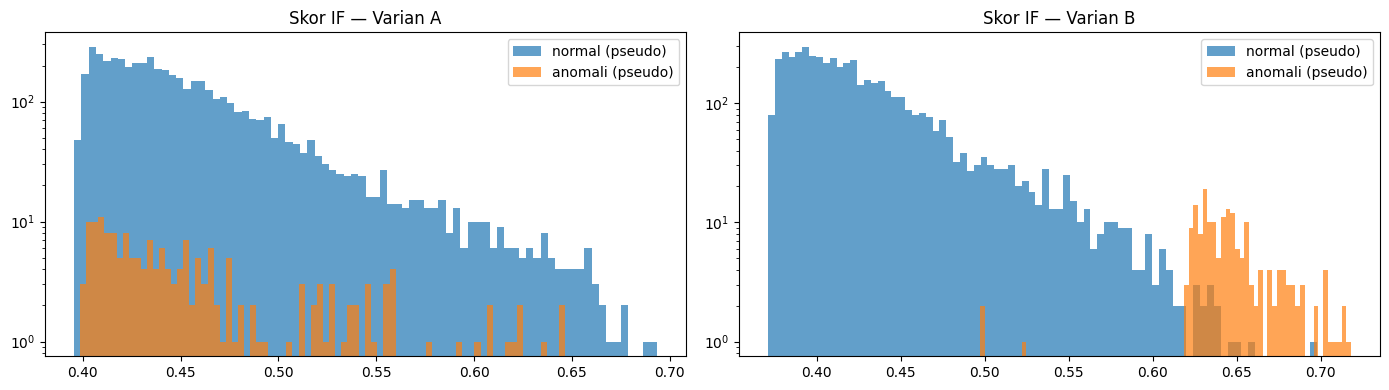

Kandidat anomali baru: 13
      block_index tx_recipient  tx_energy  price_dev  latency_resid  \
167            20       CON-03     1.6456     0.0037        -0.0006   
4185          397       CON-03     3.2857     0.0255        -0.0001   
4872          460       CON-06     1.9856     0.0103         0.0008   
1048          101       CON-14     1.1683     0.0216        -0.0002   
1911          183       CON-03     0.8250     0.0101        -0.0002   
4307          406       CON-12     1.5623     0.0243         0.0001   
4206          400       CON-03     1.1888     0.0056         0.0002   
4020          382       CON-10     1.6638     0.0186         0.0005   
4257          403       CON-11     0.3713     0.0207         0.0002   
173            20       CON-03     1.1017     0.0246        -0.0006   
1912          183       CON-03     2.6335     0.0219        -0.0002   
3759          354       CON-10     0.5233     0.0250         0.0002   
4959          467       CON-04     1.2524     0.025

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, v in zip(axes, ['A', 'B']):
    ax.hist(fe.loc[fe['pseudo_label']==0, f'score_{v}'], bins=80, 
            alpha=0.7, label='normal (pseudo)')
    ax.hist(fe.loc[fe['pseudo_label']==1, f'score_{v}'], bins=80, 
            alpha=0.7, label='anomali (pseudo)')
    ax.set_yscale('log'); ax.set_title(f'Skor IF — Varian {v}')
    ax.legend()
plt.tight_layout(); plt.show()

# Anomali BARU versi Varian B: di-flag model tapi tidak oleh rules — kandidat investigasi
baru = fe[(fe['flag_B']==1) & (fe['pseudo_label']==0)] \
         .sort_values('score_B', ascending=False)
print(f"Kandidat anomali baru: {len(baru)}")
print(baru[['block_index','tx_recipient','tx_energy','price_dev',
            'latency_resid','time_to_pay','score_B']].head(15))